<a href="https://colab.research.google.com/github/aayushkhanna09/ml-lab/blob/main/ml4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

          Car       Model  Volume  Weight  CO2  Unnamed: 5
0      Toyota        Aygo    1000     790   99         NaN
1  Mitsubishi  Space Star    1200    1160   95         NaN
2       Skoda      Citigo    1000     929   95         NaN
3        Fiat         500     900     865   90         NaN
4        Mini      Cooper    1500    1140  105         NaN
Columns: Index(['Car', 'Model', 'Volume', 'Weight', 'CO2', 'Unnamed: 5'], dtype='object')
              Volume    Weight       CO2  Unnamed: 5
Volume      1.000000  0.753537  0.592082         NaN
Weight      0.753537  1.000000  0.552150         NaN
CO2         0.592082  0.552150  1.000000         NaN
Unnamed: 5       NaN       NaN       NaN         NaN


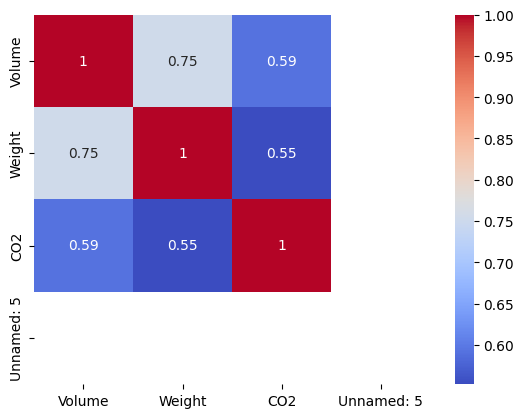

Intercept: 84.21502006695282
Coefficients: [0.00428741 0.00804928]


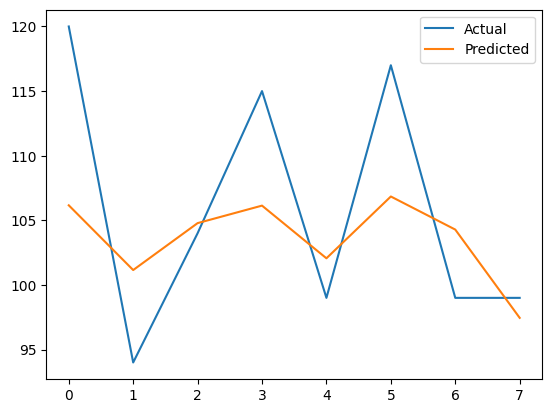

MAE: 6.335639624274503
MSE: 58.07928583657771
RMSE: 7.620976698335832


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load dataset
data = pd.read_csv("DATA.csv")

print(data.head())
print("Columns:", data.columns)

# Select numeric columns only
numeric_data = data.select_dtypes(include=['number'])

# Correlation
corr = numeric_data.corr()
print(corr)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Feature selection
X = data[['Volume', 'Weight']]
y = data['CO2']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Prediction
y_pred = model.predict(X_test)

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
